**Task 4 — Shots on Target**
**FIFA World Cup 2026**

**Stage 1 — Analytic question**

**Among teams at the FIFA World Cup 2026, did teams that went on to reach the quarter-finals
generate more shots on target per match during the group stage than teams that were eliminated
at the group stage?**

Only group-stage matches are compared. Every team plays exactly three of them and they are all
90 minutes, so there is no extra time to correct for. It also means the measurement is taken
before anyone knew which teams would progress — the question is whether attacking output was an
early signal, not whether successful teams look successful afterwards.

- **Compared:** teams that reached the quarter-finals vs teams eliminated in the group stage
- **Excluded:** teams knocked out in the Round of 32 or Round of 16
- **Main variable:** shots on target per match
- **Second variable:** shot accuracy (shots on target ÷ total shots)

**H₀:** the two groups average the same shots on target
**H₁:** the two groups differ — two-tailed, α = 0.05

**Stage 2 — Data wrangling**

The source file records **one row per player per match**, with shots and shots on target for each
appearance.

One structural issue must be corrected first. The **match and team labels appear only on the first
player of each block**, leaving the remaining rows blank as an artefact of the spreadsheet's
formatting. Grouping by team before correcting this would discard the majority of the data. A
**forward fill** carries each label down to the rows it belongs to.

In [1]:
# Stage 2 - load the player data and fix the blank labels

import pandas as pd
import numpy as np

p = pd.read_excel("Players.xlsx")
print("rows, columns:", p.shape)

print("\nblank cells in the label columns:")
print(p[["game", "team", "game_id"]].isna().sum())

for c in ["game", "team", "game_id"]:
    p[c] = p[c].ffill()
p["match_date"] = pd.to_datetime(p["game"].str[:10])

print("\nafter filling:", p[["game", "team", "game_id"]].isna().sum().sum(), "blanks left")
print("matches:", p.game_id.nunique(), " teams:", p.team.nunique(), " players:", p.player.nunique())
print()
p[["game", "team", "player", "Performance_Sh", "Performance_SoT"]].head()

rows, columns: (3288, 27)

blank cells in the label columns:
game       3184
team       3080
game_id       0
dtype: int64

after filling: 0 blanks left
matches: 104  teams: 48  players: 1039



,game,team,player,Performance_Sh,Performance_SoT
0,2026-06-11 Korea Republic-Czechia,Czechia,Adam Hložek,2,1
1,2026-06-11 Korea Republic-Czechia,Czechia,Alexandr Sojka,0,0
2,2026-06-11 Korea Republic-Czechia,Czechia,Jaroslav Zelený,0,0
3,2026-06-11 Korea Republic-Czechia,Czechia,Ladislav Krejčí,1,1
4,2026-06-11 Korea Republic-Czechia,Czechia,Lukáš Provod,0,0


The analysis concerns **teams rather than individuals**, so the player rows are aggregated into one
row per team per match. With 104 matches and two teams in each, the result should contain
**208 rows**.

No column records the tournament round, but the **number of matches a team played** identifies it.
Every team plays three group-stage matches, then one additional match for each knockout round
survived. Deriving the round this way avoids relying on a manually entered list of team names.
Sorting each team's matches by date, the **first three** are its group-stage fixtures.

In [2]:
# Stage 3 - aggregate to team level, derive the groups, save

tm = p.groupby(["game_id", "match_date", "team"], as_index=False).agg(
    shots_on_target=("Performance_SoT", "sum"),
    total_shots=("Performance_Sh", "sum"))

played = tm.groupby("team")["game_id"].transform("size")
rounds = {3: "Group Stage", 4: "Round of 32", 5: "Round of 16",
          6: "Quarter-final", 7: "Semi-final or later", 8: "Semi-final or later"}
tm["exit_round"] = played.map(rounds)

tm = tm.sort_values(["team", "match_date"])
tm["is_group_stage"] = tm.groupby("team").cumcount() < 3
tm["shot_accuracy"] = (tm["shots_on_target"] / tm["total_shots"]).round(4)

tm = tm[["game_id", "team", "exit_round", "is_group_stage",
         "shots_on_target", "total_shots", "shot_accuracy"]]
tm = tm.sort_values(["game_id", "team"]).reset_index(drop=True)
tm.to_csv("team_match_shots.csv", index=False, encoding="utf-8-sig")

print("player rows", len(p), " ->  team-match rows", len(tm))
print("rows per match       ", tm.groupby("game_id").size().unique())
print("missing values       ", tm.isna().sum().sum())
print("on target <= total   ", (tm.shots_on_target <= tm.total_shots).all())
print("total shots on target", tm.shots_on_target.sum())
print()
print(tm.groupby("exit_round")["team"].nunique().sort_values().to_string())
print("\nsaved team_match_shots.csv")
tm.head()

player rows 3288  ->  team-match rows 208
rows per match        [2]
missing values        0
on target <= total    True
total shots on target 886

exit_round
Quarter-final           4
Semi-final or later     4
Round of 16             8
Group Stage            16
Round of 32            16

saved team_match_shots.csv


,game_id,team,exit_round,is_group_stage,shots_on_target,total_shots,shot_accuracy
0,02f675d6,Czechia,Group Stage,True,3,14,0.2143
1,02f675d6,South Africa,Round of 32,True,4,17,0.2353
2,0ef71ab6,Brazil,Round of 16,True,9,21,0.4286
3,0ef71ab6,Scotland,Group Stage,True,5,14,0.3571
4,0fcac1d8,Saudi Arabia,Group Stage,True,1,3,0.3333


**Stage 3 — Data preparation and sampling**

The question concerns only group-stage matches and only two of the five exit rounds, so the table
is filtered to those records first. This leaves **72 observations**: 8 quarter-finalist teams and
16 group-stage teams, contributing three matches each.

These 72 records form the **population**. A **sample** is then drawn from them, since the purpose
of the inferential stages is to estimate a population parameter from a smaller sample rather than
to describe every available record.

The sample is **stratified**: 75 per cent is drawn from each group separately rather than from the
combined pool. The two groups differ in size, so an unstratified draw could under-represent the
smaller group by chance. The **random seed is fixed** so the sample is reproducible.

In [3]:
# Stage 4 - define the population and draw the sample

import pandas as pd
import numpy as np

tm = pd.read_csv("team_match_shots.csv")

qf_rounds = ["Quarter-final", "Semi-final or later"]
tm["comparison_group"] = np.where(tm.exit_round.isin(qf_rounds), "Quarter-Finalist",
                         np.where(tm.exit_round == "Group Stage", "Group Stage Exit", None))

population = tm[tm.is_group_stage & tm.comparison_group.notna()].copy()

print("POPULATION")
print("rows", len(population))
print(population.comparison_group.value_counts().to_string())
print("teams", population.groupby("comparison_group").team.nunique().to_dict())
print("matches per team", population.groupby("team").size().unique())

sample = population.groupby("comparison_group", group_keys=False).sample(frac=0.75, random_state=140)
sample.to_csv("analysis_sample.csv", index=False, encoding="utf-8-sig")

print("\nSAMPLE")
print("rows", len(sample), "of", len(population), "=", round(len(sample)/len(population)*100), "%")
print(sample.comparison_group.value_counts().to_string())
print("teams", sample.groupby("comparison_group").team.nunique().to_dict())
print("\nsaved analysis_sample.csv")

POPULATION
rows 72
comparison_group
Group Stage Exit    48
Quarter-Finalist    24
teams {'Group Stage Exit': 16, 'Quarter-Finalist': 8}
matches per team [3]

SAMPLE
rows 54 of 72 = 75 %
comparison_group
Group Stage Exit    36
Quarter-Finalist    18
teams {'Group Stage Exit': 16, 'Quarter-Finalist': 8}

saved analysis_sample.csv


**Stage 4 — Descriptive statistics**

The sample is summarised before any test is applied.

**Spread is reported alongside the average**, since two groups can share a mean while differing
substantially in consistency. Standard deviation, range and quartiles are included for both
variables.

In [4]:
# Stage 5 - summarise the sample

sample = pd.read_csv("analysis_sample.csv")

print("SHOTS ON TARGET")
print(sample.groupby("comparison_group")["shots_on_target"].agg(
    n="count", mean="mean", median="median", std="std", min="min", max="max").round(2))

print("\nSHOT ACCURACY")
print(sample.groupby("comparison_group")["shot_accuracy"].agg(
    n="count", mean="mean", median="median", std="std", min="min", max="max").round(3))

print("\nQUARTILES - shots on target")
print(sample.groupby("comparison_group")["shots_on_target"].quantile([.25, .5, .75]).round(2))

SHOTS ON TARGET
                   n  mean  median   std  min  max
comparison_group                                  
Group Stage Exit  36  2.97     3.0  2.24    0   10
Quarter-Finalist  18  6.17     6.5  2.50    2   11

SHOT ACCURACY
                   n   mean  median    std    min    max
comparison_group                                        
Group Stage Exit  36  0.268   0.283  0.143  0.000  0.571
Quarter-Finalist  18  0.393   0.382  0.163  0.158  0.727

QUARTILES - shots on target
comparison_group      
Group Stage Exit  0.25    1.75
                  0.50    3.00
                  0.75    4.00
Quarter-Finalist  0.25    4.25
                  0.50    6.50
                  0.75    7.75
Name: shots_on_target, dtype: float64


The same comparison is shown visually: a **boxplot** of shots on target, the **frequency** of each
count, and a **boxplot** of shot accuracy.

**Plum and gold** are used in place of the more common red and green pairing, as those two hues
are difficult to distinguish for readers with red-green colour vision deficiency.

saved fig1_distributions.png


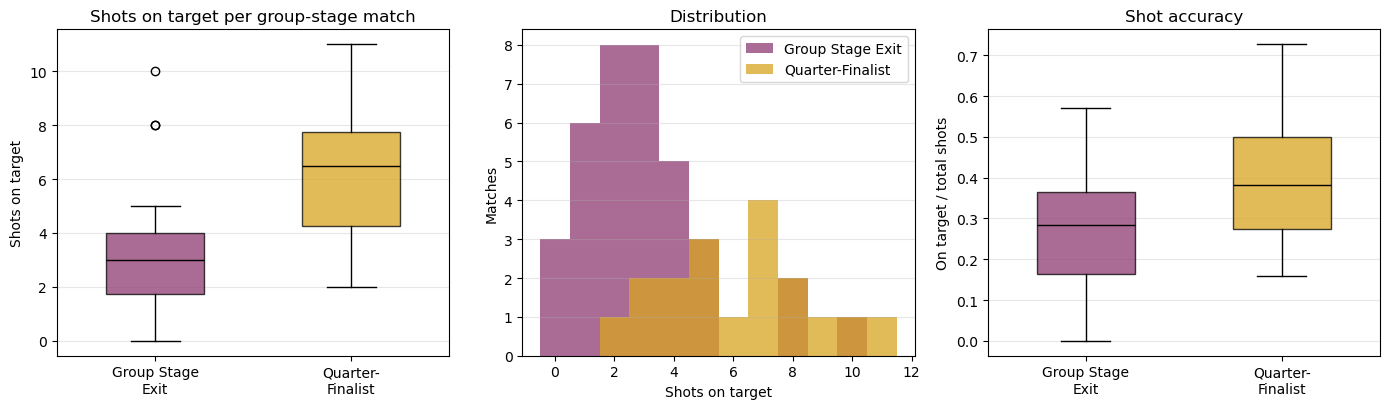

In [5]:
# Stage 6 - charts

import matplotlib.pyplot as plt

qf = sample[sample.comparison_group == "Quarter-Finalist"]
ex = sample[sample.comparison_group == "Group Stage Exit"]

plum, gold = "#8E3B72", "#D9A521"
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))

bp = ax[0].boxplot([ex.shots_on_target, qf.shots_on_target], patch_artist=True,
                   tick_labels=["Group Stage\nExit", "Quarter-\nFinalist"], widths=0.5)
for patch, c in zip(bp["boxes"], [plum, gold]):
    patch.set_facecolor(c); patch.set_alpha(0.75)
for med in bp["medians"]:
    med.set_color("black")
ax[0].set_title("Shots on target per group-stage match")
ax[0].set_ylabel("Shots on target")
ax[0].grid(axis="y", alpha=0.3)

bins = np.arange(0, sample.shots_on_target.max() + 2) - 0.5
ax[1].hist(ex.shots_on_target, bins=bins, alpha=0.75, color=plum, label="Group Stage Exit")
ax[1].hist(qf.shots_on_target, bins=bins, alpha=0.75, color=gold, label="Quarter-Finalist")
ax[1].set_title("Distribution")
ax[1].set_xlabel("Shots on target")
ax[1].set_ylabel("Matches")
ax[1].legend()
ax[1].grid(axis="y", alpha=0.3)

bp2 = ax[2].boxplot([ex.shot_accuracy, qf.shot_accuracy], patch_artist=True,
                    tick_labels=["Group Stage\nExit", "Quarter-\nFinalist"], widths=0.5)
for patch, c in zip(bp2["boxes"], [plum, gold]):
    patch.set_facecolor(c); patch.set_alpha(0.75)
for med in bp2["medians"]:
    med.set_color("black")
ax[2].set_title("Shot accuracy")
ax[2].set_ylabel("On target / total shots")
ax[2].grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig("fig1_distributions.png", dpi=150)
print("saved fig1_distributions.png")

**Stage 5 — Inferential statistics: confidence interval**

The sample produces a single estimate of each group's mean. A **confidence interval** expresses
how far the true population mean is likely to lie from that estimate.

At **95 per cent confidence**, approximately 95 of every 100 intervals constructed by this method
would contain the true value. The **t-distribution** is used because the population standard
deviation is unknown and must be estimated from the sample.

The **interval for the difference** between the two means carries the most weight. If it
**excludes zero**, "no difference between the groups" is not a plausible conclusion.

In [6]:
# Stage 7 - confidence intervals

import pandas as pd
import numpy as np
import scipy.stats as st

sample = pd.read_csv("analysis_sample.csv")
qf = sample[sample.comparison_group == "Quarter-Finalist"]
ex = sample[sample.comparison_group == "Group Stage Exit"]

def ci(x):
    n, m, se = len(x), x.mean(), st.sem(x)
    lo, hi = st.t.interval(0.95, n - 1, loc=m, scale=se)
    return n, m, x.std(ddof=1), se, lo, hi

print("95% CONFIDENCE INTERVALS - shots on target")
for name, x in [("Group Stage Exit", ex.shots_on_target), ("Quarter-Finalist", qf.shots_on_target)]:
    n, m, sd, se, lo, hi = ci(x)
    print(f"  {name:18s} n={n:2d}  mean={m:.2f}  sd={sd:.2f}  se={se:.2f}  95% CI [{lo:.2f}, {hi:.2f}]")

print("\n95% CONFIDENCE INTERVALS - shot accuracy")
for name, x in [("Group Stage Exit", ex.shot_accuracy), ("Quarter-Finalist", qf.shot_accuracy)]:
    n, m, sd, se, lo, hi = ci(x)
    print(f"  {name:18s} n={n:2d}  mean={m:.3f}  sd={sd:.3f}  se={se:.3f}  95% CI [{lo:.3f}, {hi:.3f}]")

a, b = qf.shots_on_target, ex.shots_on_target
diff = a.mean() - b.mean()
se_d = np.sqrt(a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))
df_w = (a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))**2 / (
        (a.var(ddof=1)/len(a))**2/(len(a)-1) + (b.var(ddof=1)/len(b))**2/(len(b)-1))
lo_d, hi_d = st.t.interval(0.95, df_w, loc=diff, scale=se_d)

print("\nDIFFERENCE IN MEANS - shots on target")
print(f"  quarter-finalist minus group stage exit = {diff:.2f}")
print(f"  95% CI [{lo_d:.2f}, {hi_d:.2f}]   df={df_w:.1f}")
print(f"  interval contains zero: {lo_d <= 0 <= hi_d}")

95% CONFIDENCE INTERVALS - shots on target
  Group Stage Exit   n=36  mean=2.97  sd=2.24  se=0.37  95% CI [2.22, 3.73]
  Quarter-Finalist   n=18  mean=6.17  sd=2.50  se=0.59  95% CI [4.92, 7.41]

95% CONFIDENCE INTERVALS - shot accuracy
  Group Stage Exit   n=36  mean=0.268  sd=0.143  se=0.024  95% CI [0.220, 0.316]
  Quarter-Finalist   n=18  mean=0.393  sd=0.163  se=0.038  95% CI [0.312, 0.474]

DIFFERENCE IN MEANS - shots on target
  quarter-finalist minus group stage exit = 3.19
  95% CI [1.77, 4.62]   df=30.9
  interval contains zero: False


Each point marks a **group mean** and the bars show the **95 per cent interval** surrounding it.
The **separation between the two intervals** is the finding in visual form.

saved fig2_confidence_intervals.png


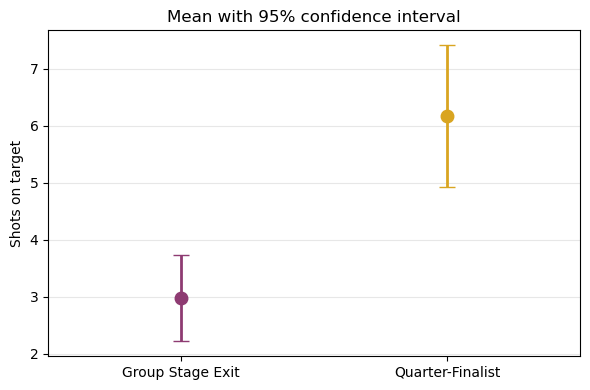

In [7]:
# Stage 8 - confidence interval chart

import matplotlib.pyplot as plt

plum, gold = "#8E3B72", "#D9A521"
fig, ax = plt.subplots(figsize=(6, 4))

for i, (x, c) in enumerate([(ex.shots_on_target, plum), (qf.shots_on_target, gold)]):
    n, m, sd, se, lo, hi = ci(x)
    ax.errorbar(i, m, yerr=[[m - lo], [hi - m]], fmt="o", color=c,
                markersize=9, capsize=6, linewidth=2)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Group Stage Exit", "Quarter-Finalist"])
ax.set_ylabel("Shots on target")
ax.set_title("Mean with 95% confidence interval")
ax.grid(axis="y", alpha=0.3)
ax.set_xlim(-0.5, 1.5)

fig.tight_layout()
fig.savefig("fig2_confidence_intervals.png", dpi=150)
print("saved fig2_confidence_intervals.png")

**Stage 6 — Inferential statistics: two-sample t-test**

The test begins by assuming **no real difference exists** and that the observed gap arose by
chance. This is the null hypothesis. The **p-value** gives the probability of observing a gap this
large under that assumption; a value below **0.05** makes chance an implausible explanation.

**Welch's** form of the test is applied because it does not require equal variances between
groups.

Two assumptions are examined beforehand. **Shapiro-Wilk** tests whether each group is normally
distributed and **Levene's test** whether the variances are comparable. **Cohen's d** is reported
alongside the p-value: the p-value indicates whether a difference exists, while d indicates its
**magnitude**.

In [8]:
# Stage 9 - assumption checks and the t-test

import pandas as pd
import numpy as np
import scipy.stats as st

sample = pd.read_csv("analysis_sample.csv")
qf = sample[sample.comparison_group == "Quarter-Finalist"]
ex = sample[sample.comparison_group == "Group Stage Exit"]
a, b = qf.shots_on_target, ex.shots_on_target

print("HYPOTHESES")
print("  H0: mean(quarter-finalist) = mean(group stage exit)")
print("  H1: mean(quarter-finalist) != mean(group stage exit)")
print("  alpha = 0.05, two-tailed")

print("\nASSUMPTION CHECKS")
for name, x in [("Group Stage Exit", b), ("Quarter-Finalist", a)]:
    w, p_s = st.shapiro(x)
    print(f"  Shapiro-Wilk {name:18s} W={w:.3f}  p={p_s:.4f}  {'normal' if p_s > .05 else 'not normal'}")
lev_w, lev_p = st.levene(b, a)
print(f"  Levene equal variance      W={lev_w:.3f}  p={lev_p:.4f}  {'equal' if lev_p > .05 else 'unequal'}")

t, p = st.ttest_ind(a, b, equal_var=False)
pooled = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
d = (a.mean() - b.mean()) / pooled

print("\nWELCH TWO-SAMPLE t-TEST - shots on target")
print(f"  t = {t:.3f}")
print(f"  p = {p:.6f}")
print(f"  Cohen's d = {d:.2f}")
print(f"  decision: {'reject H0' if p < 0.05 else 'fail to reject H0'}")

HYPOTHESES
  H0: mean(quarter-finalist) = mean(group stage exit)
  H1: mean(quarter-finalist) != mean(group stage exit)
  alpha = 0.05, two-tailed

ASSUMPTION CHECKS
  Shapiro-Wilk Group Stage Exit   W=0.878  p=0.0009  not normal
  Shapiro-Wilk Quarter-Finalist   W=0.972  p=0.8311  normal
  Levene equal variance      W=1.187  p=0.2809  equal

WELCH TWO-SAMPLE t-TEST - shots on target
  t = 4.578
  p = 0.000072
  Cohen's d = 1.37
  decision: reject H0


Shapiro-Wilk identified the group-stage data as **non-normal**, so the t-test result is examined
further rather than accepted in isolation.

**Mann-Whitney U** makes no distributional assumption; agreement between the two tests indicates
the violation did not drive the result. **Shot accuracy** addresses a related but separate
question, namely whether the difference lies in shot volume or shot quality. The **sensitivity
check** repeats the test on all 72 population records rather than the 54 sampled, confirming the
finding does not depend on which observations were drawn.

In [9]:
# Stage 10 - robustness checks

u, pu = st.mannwhitneyu(a, b, alternative="two-sided")
print("NON-PARAMETRIC CHECK - no normality assumed")
print(f"  Mann-Whitney U = {u:.1f}   p = {pu:.6f}")
print(f"  same conclusion as the t-test: {(p < 0.05) == (pu < 0.05)}")

a2, b2 = qf.shot_accuracy, ex.shot_accuracy
t2, p2 = st.ttest_ind(a2, b2, equal_var=False)
pooled2 = np.sqrt(((len(a2)-1)*a2.var(ddof=1) + (len(b2)-1)*b2.var(ddof=1)) / (len(a2)+len(b2)-2))
print("\nSECOND VARIABLE - shot accuracy")
print(f"  t = {t2:.3f}   p = {p2:.6f}   Cohen's d = {(a2.mean()-b2.mean())/pooled2:.2f}")
print(f"  decision: {'reject H0' if p2 < 0.05 else 'fail to reject H0'}")

tm = pd.read_csv("team_match_shots.csv")
qfr = ["Quarter-final", "Semi-final or later"]
tm["comparison_group"] = np.where(tm.exit_round.isin(qfr), "Quarter-Finalist",
                         np.where(tm.exit_round == "Group Stage", "Group Stage Exit", None))
pop = tm[tm.is_group_stage & tm.comparison_group.notna()]
pa = pop.loc[pop.comparison_group == "Quarter-Finalist", "shots_on_target"]
pb = pop.loc[pop.comparison_group == "Group Stage Exit", "shots_on_target"]
t3, p3 = st.ttest_ind(pa, pb, equal_var=False)

print("\nSENSITIVITY CHECK - all 72 population rows instead of the 54 sampled")
print(f"  n = {len(pa)} vs {len(pb)}   means {pa.mean():.2f} vs {pb.mean():.2f}")
print(f"  t = {t3:.3f}   p = {p3:.6f}")
print(f"  same conclusion as the sample: {(p < 0.05) == (p3 < 0.05)}")

NON-PARAMETRIC CHECK - no normality assumed
  Mann-Whitney U = 544.0   p = 0.000049
  same conclusion as the t-test: True

SECOND VARIABLE - shot accuracy
  t = 2.759   p = 0.009716   Cohen's d = 0.83
  decision: reject H0

SENSITIVITY CHECK - all 72 population rows instead of the 54 sampled
  n = 24 vs 48   means 5.96 vs 2.88
  t = 4.866   p = 0.000021
  same conclusion as the sample: True


**Stage 7 — Conclusion and limitations**

**Findings**

- Quarter-finalists averaged **6.17 shots on target** per group-stage match; teams eliminated at
  the group stage averaged **2.97** — more than double.
- The 95 per cent confidence intervals **do not overlap**: 4.92 to 7.41 against 2.22 to 3.73.
- The interval for the difference, **1.77 to 4.62**, excludes zero.
- Welch's t-test: **t = 4.578, p = 0.000072**, with **Cohen's d = 1.37**, a large effect.
- Mann-Whitney U agreed at **p = 0.000049**, so the non-normality did not drive the result.
- Repeating the test on all 72 population records gave **p = 0.000021** — the finding does not
  depend on which rows were sampled.
- Shot accuracy pointed the same way, **0.393 against 0.268** at p = 0.0097. The stronger teams
  shot both **more often** and **more accurately**.

**Conclusion**

The null hypothesis is rejected. Attacking output during the group stage distinguished eventual
quarter-finalists from teams eliminated early — measured **before the outcome of the tournament
was known**, which makes it an early indicator rather than a description of success after the
fact.

**Limitations**

- **Excluded middle tiers.** Teams knocked out in the Round of 32 and Round of 16 were left out to
  sharpen the contrast. This overstates the gap relative to the full field of 48.
- **Partial circularity.** Teams that progress further are generally stronger teams, so some of
  the difference restates that rather than revealing something specific about attacking play.
- **Non-independent observations.** Each team contributes three matches, so records within a team
  are not fully independent. The balanced design limits the effect but does not remove it.
- **Single tournament.** The result describes World Cup 2026 and cannot be assumed to generalise
  to other competitions or formats.

**Data validation**

The tournament total of **886 shots on target** derived from this file matches the figure obtained
independently from **FIFA's own match API**, indicating the source is accurate at the aggregate
level.